**Imports & Load Cleaned Data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (roc_curve, auc, precision_recall_curve, average_precision_score)

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Project Datasets/Credit Card Fraud Dataset_cleaned.csv')
print(f"Shape: {df.shape}")
print(f"Fraud rate: {df['Class'].mean()*100:.4f}%")
df.head()

Mounted at /content/drive
Shape: (50439, 31)
Fraud rate: 0.9378%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-0.212037,1.199490,0.197301,0.616923,0.554820,-0.526523,-0.785182,-0.036202,-0.070460,-0.224568,...,-0.191542,-0.597586,0.148051,0.529668,0.158453,0.064369,-0.033132,0.011166,-0.258572,0
1,0.400096,2.054939,-0.005134,-1.050691,0.401563,-0.047484,-1.112092,0.218426,-0.350042,0.430742,...,-0.275390,-0.616070,0.338719,0.006520,-0.288834,0.198696,-0.062744,-0.059034,-0.290894,0
2,-0.202048,-0.943726,-0.366261,2.292128,-1.909816,-0.305247,1.903637,-0.998268,0.757791,0.170689,...,0.109482,0.651761,-0.502554,-1.659885,0.669679,-0.000532,0.228359,0.088451,-0.280916,0
3,-0.921194,-0.960946,0.864361,1.286077,0.131434,0.630708,-0.746227,0.567456,-0.281288,0.965197,...,-0.375636,-0.589018,0.275299,-0.161066,-0.491036,-0.020583,0.150700,0.179427,-0.233699,0
4,0.884182,1.688499,0.142083,-2.975027,0.857739,0.752403,-1.699499,0.883376,-0.527584,-0.050348,...,0.021742,-0.179006,-0.069067,0.967166,0.029453,0.613583,-0.095408,0.044466,2.431282,0


**Train / Test Split**

In [2]:
X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train fraud rate: {y_train.mean()*100:.4f}%")
print(f"Test  fraud rate: {y_test.mean()*100:.4f}%")

Train: (40351, 30)  |  Test: (10088, 30)
Train fraud rate: 0.9368%
Test  fraud rate: 0.9417%


**Helper Functions**

In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.model_selection import cross_val_score

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()

def evaluate_model(name, y_true, y_pred, y_prob):
    accuracy  = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    roc_auc   = roc_auc_score(y_true, y_prob)
    print(f"--- {name} ---")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {roc_auc:.4f}")
    return {"Model": name, "Accuracy": accuracy, "Precision": precision,
            "Recall": recall, "F1": f1, "ROC-AUC": roc_auc}

def compare_models(results):
    return pd.DataFrame(results).sort_values("F1", ascending=False)

def cross_validate_model(model, X, y, cv=5):
    f1_scores = cross_val_score(model, X, y, cv=cv, scoring="f1", n_jobs=-1)
    print(f"F1 Scores (5-Fold CV): {f1_scores.round(3)}")
    print(f"Mean F1: {f1_scores.mean():.4f} (+/- {f1_scores.std():.4f})")
    return f1_scores

**Model 1 — Logistic Regression**

--- Logistic Regression ---
Accuracy : 0.9752
Precision: 0.2659
Recall   : 0.9263
F1 Score : 0.4131
ROC AUC  : 0.9776


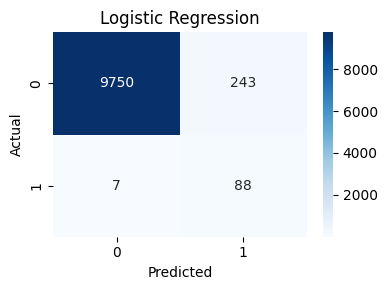

In [4]:
lr = LogisticRegression(max_iter=2000, random_state=42, class_weight="balanced")
lr.fit(X_train, y_train)
pred_lr  = lr.predict(X_test)
prob_lr  = lr.predict_proba(X_test)[:, 1]
m_lr = evaluate_model("Logistic Regression", y_test, pred_lr, prob_lr)
plot_confusion_matrix(y_test, pred_lr, "Logistic Regression"); plt.show()

**Model 2 — Decision Tree**

--- Decision Tree ---
Accuracy : 0.9732
Precision: 0.2434
Recall   : 0.8737
F1 Score : 0.3807
ROC AUC  : 0.9313


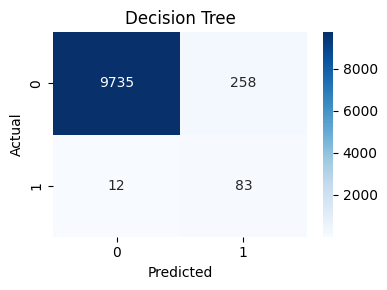

In [5]:
dt = DecisionTreeClassifier(random_state=42, class_weight="balanced", max_depth=8)
dt.fit(X_train, y_train)
pred_dt  = dt.predict(X_test)
prob_dt  = dt.predict_proba(X_test)[:, 1]
m_dt = evaluate_model("Decision Tree", y_test, pred_dt, prob_dt)
plot_confusion_matrix(y_test, pred_dt, "Decision Tree"); plt.show()

**Model 3 — Random Forest**

--- Random Forest ---
Accuracy : 0.9983
Precision: 0.9756
Recall   : 0.8421
F1 Score : 0.9040
ROC AUC  : 0.9803


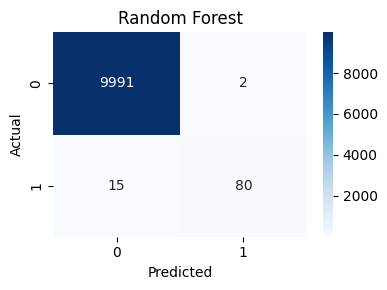

In [6]:
rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced", n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf  = rf.predict(X_test)
prob_rf  = rf.predict_proba(X_test)[:, 1]
m_rf = evaluate_model("Random Forest", y_test, pred_rf, prob_rf)
plot_confusion_matrix(y_test, pred_rf, "Random Forest"); plt.show()

**Model 4 — KNN (with K optimization)**

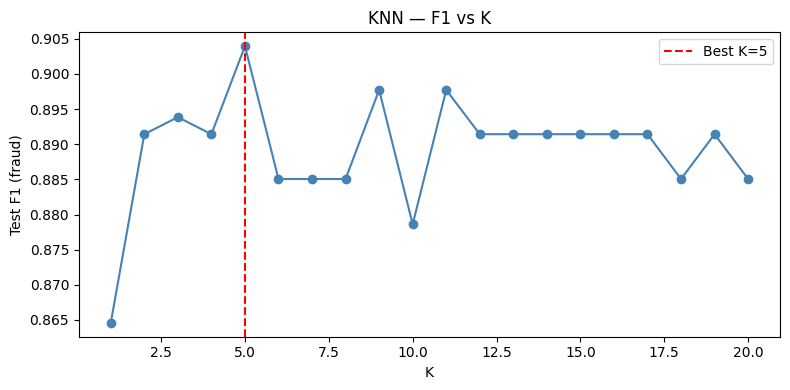

Best K = 5
--- KNN (K=5) ---
Accuracy : 0.9983
Precision: 0.9756
Recall   : 0.8421
F1 Score : 0.9040
ROC AUC  : 0.9469


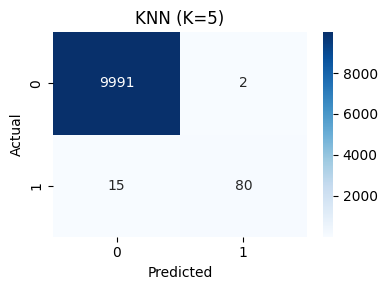

In [7]:
ks = list(range(1, 21))
f1_scores = []
for k in ks:
    kk = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    kk.fit(X_train, y_train)
    from sklearn.metrics import f1_score
    f1_scores.append(f1_score(y_test, kk.predict(X_test), zero_division=0))

best_k = ks[int(np.argmax(f1_scores))]
plt.figure(figsize=(8, 4))
plt.plot(ks, f1_scores, marker="o", color="steelblue")
plt.axvline(best_k, color="red", linestyle="--", label=f"Best K={best_k}")
plt.xlabel("K"); plt.ylabel("Test F1 (fraud)"); plt.title("KNN — F1 vs K")
plt.legend(); plt.tight_layout(); plt.show()
print(f"Best K = {best_k}")

knn = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)
prob_knn = knn.predict_proba(X_test)[:, 1]
m_knn = evaluate_model(f"KNN (K={best_k})", y_test, pred_knn, prob_knn)
plot_confusion_matrix(y_test, pred_knn, f"KNN (K={best_k})"); plt.show()

**Model 5 — SVM**

SVM training subset: 15,000 rows  (fraud=378, legit=14622)
--- SVM ---
Accuracy : 0.9889
Precision: 0.4555
Recall   : 0.9158
F1 Score : 0.6084
ROC AUC  : 0.9874


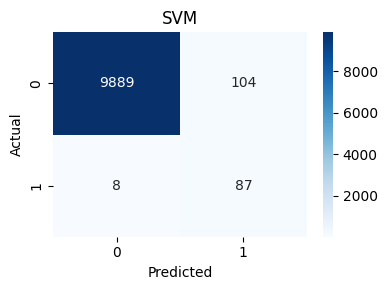

In [8]:
# Stratified subsample: keep all fraud + random sample of legitimate to reach 15k total
fraud_idx  = X_train[y_train == 1].index
legit_idx  = X_train[y_train == 0].index
n_legit    = min(15000 - len(fraud_idx), len(legit_idx))
sampled_legit = np.random.RandomState(42).choice(legit_idx, size=n_legit, replace=False)
svm_idx    = np.concatenate([fraud_idx, sampled_legit])

X_svm = X_train.loc[svm_idx]
y_svm = y_train.loc[svm_idx]
print(f"SVM training subset: {X_svm.shape[0]:,} rows  "
      f"(fraud={y_svm.sum()}, legit={(y_svm==0).sum()})")

svm = SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42)
svm.fit(X_svm, y_svm)
pred_svm = svm.predict(X_test)
prob_svm = svm.predict_proba(X_test)[:, 1]
m_svm = evaluate_model("SVM", y_test, pred_svm, prob_svm)
plot_confusion_matrix(y_test, pred_svm, "SVM"); plt.show()

**Model 6 — Gradient Boosting**

--- Gradient Boosting ---
Accuracy : 0.9971
Precision: 0.8587
Recall   : 0.8316
F1 Score : 0.8449
ROC AUC  : 0.9630


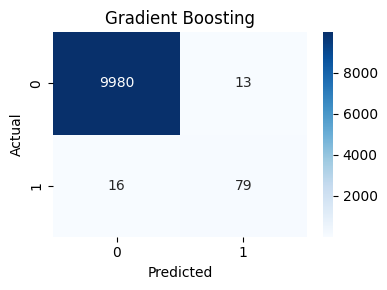

In [9]:
gb = GradientBoostingClassifier(random_state=42, n_estimators=200, max_depth=4, learning_rate=0.1)
gb.fit(X_train, y_train)
pred_gb  = gb.predict(X_test)
prob_gb  = gb.predict_proba(X_test)[:, 1]
m_gb = evaluate_model("Gradient Boosting", y_test, pred_gb, prob_gb)
plot_confusion_matrix(y_test, pred_gb, "Gradient Boosting"); plt.show()

**Model 7 — Naive Bayes**

--- Naive Bayes ---
Accuracy : 0.9735
Precision: 0.2471
Recall   : 0.8842
F1 Score : 0.3862
ROC AUC  : 0.9750


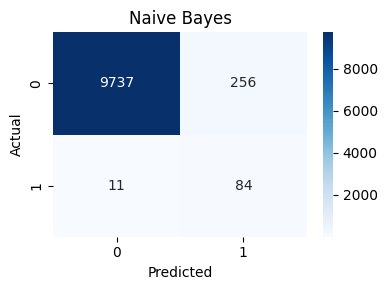

In [10]:
nb = GaussianNB()
nb.fit(X_train, y_train)
pred_nb  = nb.predict(X_test)
prob_nb  = nb.predict_proba(X_test)[:, 1]
m_nb = evaluate_model("Naive Bayes", y_test, pred_nb, prob_nb)
plot_confusion_matrix(y_test, pred_nb, "Naive Bayes"); plt.show()

**Model Comparison**

In [11]:
results = [m_lr, m_dt, m_rf, m_knn, m_svm, m_gb, m_nb]
df_results = compare_models(results)
print(df_results.round(4).to_string(index=False))

              Model  Accuracy  Precision  Recall     F1  ROC-AUC
      Random Forest    0.9983     0.9756  0.8421 0.9040   0.9803
          KNN (K=5)    0.9983     0.9756  0.8421 0.9040   0.9469
  Gradient Boosting    0.9971     0.8587  0.8316 0.8449   0.9630
                SVM    0.9889     0.4555  0.9158 0.6084   0.9874
Logistic Regression    0.9752     0.2659  0.9263 0.4131   0.9776
        Naive Bayes    0.9735     0.2471  0.8842 0.3862   0.9750
      Decision Tree    0.9732     0.2434  0.8737 0.3807   0.9313


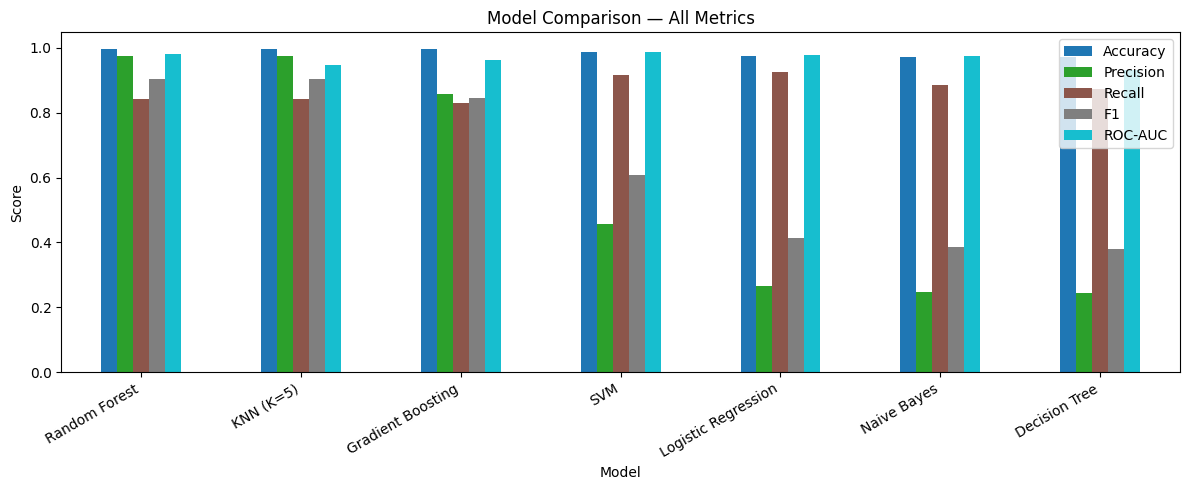

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
df_plot = df_results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]]
df_plot.plot(kind="bar", ax=ax, colormap="tab10")
ax.set_title("Model Comparison — All Metrics")
ax.set_ylabel("Score")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

**5-Fold Cross-Validation (F1)**

In [13]:
cv_models = {
    "Logistic Regression": (lr, X_train),
    "Decision Tree":       (dt, X_train),
    "Random Forest":       (rf, X_train),
    f"KNN (K={best_k})":   (knn, X_train),
    "SVM":                 (svm, X_svm),     # subsample used for SVM
    "Gradient Boosting":   (gb, X_train),
    "Naive Bayes":         (nb, X_train),
}
cv_ytrain_map = {
    "Logistic Regression": y_train,
    "Decision Tree":       y_train,
    "Random Forest":       y_train,
    f"KNN (K={best_k})":   y_train,
    "SVM":                 y_svm,
    "Gradient Boosting":   y_train,
    "Naive Bayes":         y_train,
}
cv_scores = {}
for name, (m, X_in) in cv_models.items():
    print(f"\n{name}")
    cv_scores[name] = cross_validate_model(m, X_in, cv_ytrain_map[name], cv=5)


Logistic Regression
F1 Scores (5-Fold CV): [0.386 0.404 0.383 0.414 0.389]
Mean F1: 0.3950 (+/- 0.0116)

Decision Tree
F1 Scores (5-Fold CV): [0.527 0.422 0.423 0.559 0.494]
Mean F1: 0.4851 (+/- 0.0549)

Random Forest
F1 Scores (5-Fold CV): [0.91  0.824 0.857 0.876 0.891]
Mean F1: 0.8717 (+/- 0.0294)

KNN (K=5)
F1 Scores (5-Fold CV): [0.89  0.83  0.822 0.871 0.886]
Mean F1: 0.8598 (+/- 0.0287)

SVM
F1 Scores (5-Fold CV): [0.71  0.78  0.723 0.763 0.726]
Mean F1: 0.7405 (+/- 0.0267)

Gradient Boosting
F1 Scores (5-Fold CV): [0.846 0.809 0.817 0.778 0.837]
Mean F1: 0.8171 (+/- 0.0238)

Naive Bayes
F1 Scores (5-Fold CV): [0.404 0.358 0.372 0.39  0.373]
Mean F1: 0.3794 (+/- 0.0158)


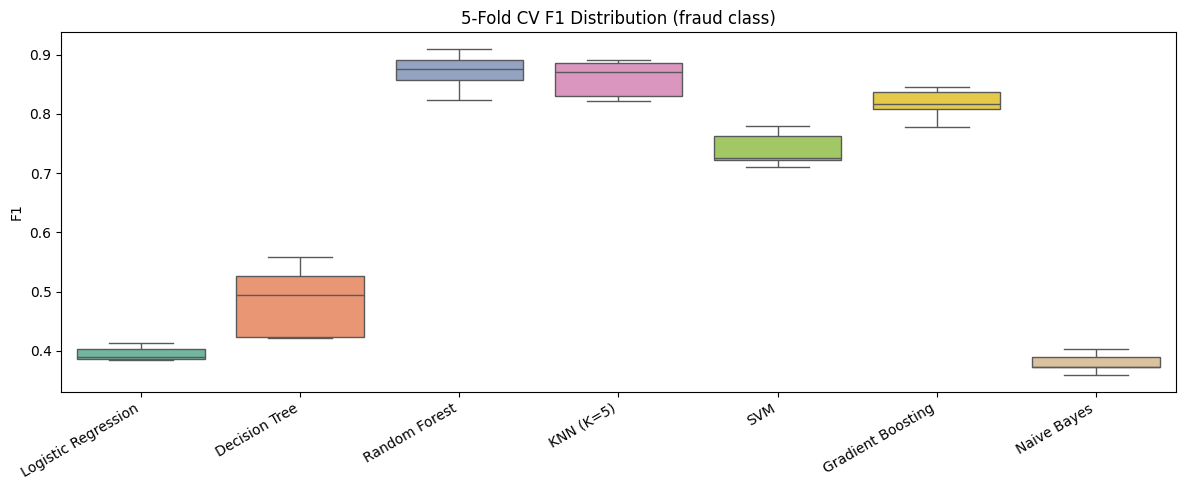

In [14]:
cv_df = pd.DataFrame(cv_scores)
plt.figure(figsize=(12, 5))
sns.boxplot(data=cv_df, palette="Set2")
plt.title("5-Fold CV F1 Distribution (fraud class)")
plt.xticks(rotation=30, ha="right"); plt.ylabel("F1")
plt.tight_layout(); plt.show()

**ROC Curves and Precision-Recall Curves**

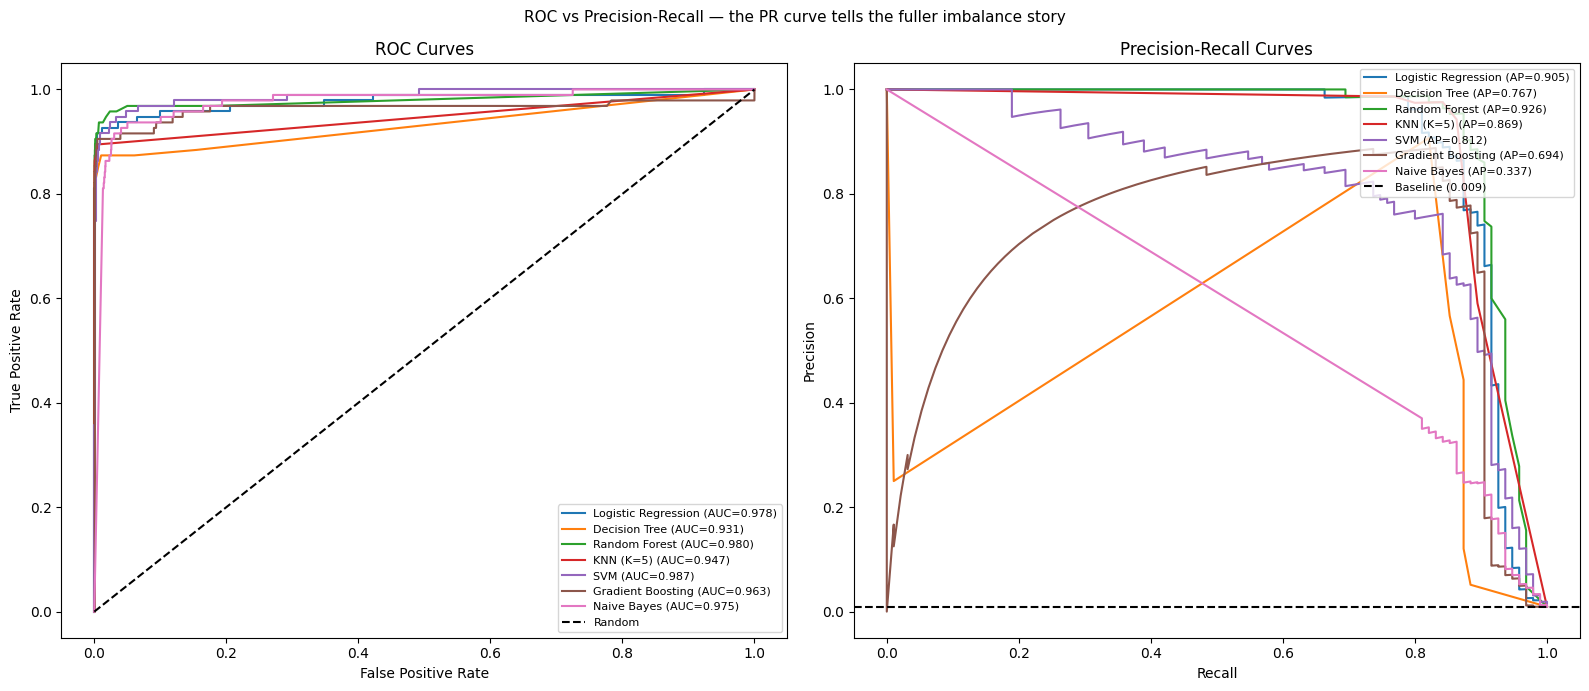

In [15]:
model_probs = {
    "Logistic Regression": prob_lr,
    "Decision Tree":       prob_dt,
    "Random Forest":       prob_rf,
    f"KNN (K={best_k})":   prob_knn,
    "SVM":                 prob_svm,
    "Gradient Boosting":   prob_gb,
    "Naive Bayes":         prob_nb,
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ROC
for name, prob in model_probs.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")
axes[0].plot([0,1],[0,1],"k--", label="Random")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves"); axes[0].legend(loc="lower right", fontsize=8)

# PR
for name, prob in model_probs.items():
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    axes[1].plot(rec, prec, label=f"{name} (AP={ap:.3f})")
baseline_pr = y_test.mean()
axes[1].axhline(baseline_pr, color="k", linestyle="--", label=f"Baseline ({baseline_pr:.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves"); axes[1].legend(loc="upper right", fontsize=8)

plt.suptitle("ROC vs Precision-Recall — the PR curve tells the fuller imbalance story", fontsize=11)
plt.tight_layout(); plt.show()

**Hyperparameter Tuning — Random Forest**

In [16]:
param_grid = {
    "n_estimators": [200, 400],
    "max_depth":    [None, 20],
    "min_samples_leaf": [1, 2],
}
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=-1),
    param_grid, cv=3, scoring="f1", n_jobs=-1, verbose=1)
grid_rf.fit(X_train, y_train)
print(f"Best params : {grid_rf.best_params_}")
print(f"Best CV F1  : {grid_rf.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params : {'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 200}
Best CV F1  : 0.8763


--- Random Forest (Tuned) ---
Accuracy : 0.9982
Precision: 0.9639
Recall   : 0.8421
F1 Score : 0.8989
ROC AUC  : 0.9789


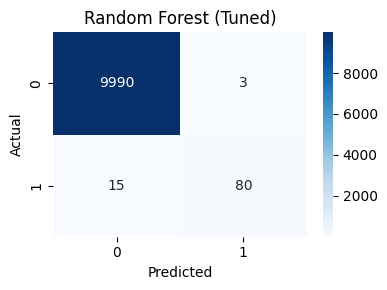

In [17]:
rf_tuned    = grid_rf.best_estimator_
pred_rf_t   = rf_tuned.predict(X_test)
prob_rf_t   = rf_tuned.predict_proba(X_test)[:, 1]
m_rf_t = evaluate_model("Random Forest (Tuned)", y_test, pred_rf_t, prob_rf_t)
plot_confusion_matrix(y_test, pred_rf_t, "Random Forest (Tuned)"); plt.show()

**Feature Importance — Tuned Random Forest**

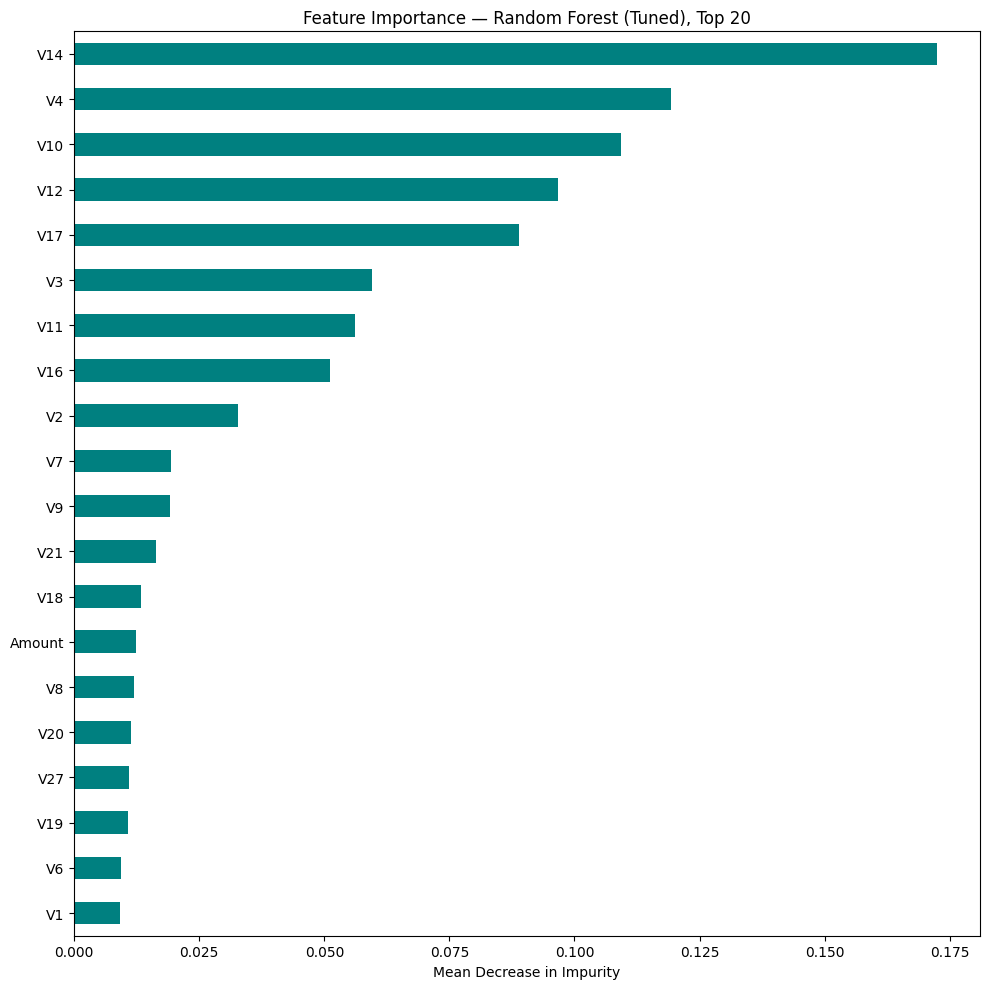

Top 10 features:
V7     0.0193
V2     0.0327
V16    0.0511
V11    0.0562
V3     0.0594
V17    0.0889
V12    0.0966
V10    0.1093
V4     0.1193
V14    0.1725
dtype: float64


In [18]:
importances = pd.Series(rf_tuned.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(10, 10))
importances.tail(20).plot(kind="barh", color="teal")
plt.title("Feature Importance — Random Forest (Tuned), Top 20")
plt.xlabel("Mean Decrease in Impurity")
plt.tight_layout(); plt.show()

print("Top 10 features:")
print(importances.tail(10).round(4))

**Prediction Example**

In [19]:
sample_fraud = X_test[y_test == 1].head(3)
sample_legit = X_test[y_test == 0].head(3)
sample       = pd.concat([sample_fraud, sample_legit])
y_sample     = y_test.loc[sample.index]

preds_s = rf_tuned.predict(sample)
probs_s = rf_tuned.predict_proba(sample)[:, 1]

print(f"{'#':<4} {'Actual':<12} {'Predicted':<14} {'P(fraud)':<10}")
print("-" * 44)
for i, (idx, actual) in enumerate(y_sample.items()):
    act_label  = "Fraud" if actual == 1 else "Legitimate"
    pred_label = "Fraud" if preds_s[i] == 1 else "Legitimate"
    print(f"{i:<4} {act_label:<12} {pred_label:<14} {probs_s[i]:.4f}")

#    Actual       Predicted      P(fraud)  
--------------------------------------------
0    Fraud        Fraud          0.9696
1    Fraud        Legitimate     0.0050
2    Fraud        Fraud          0.9895
3    Legitimate   Legitimate     0.0000
4    Legitimate   Legitimate     0.0000
5    Legitimate   Legitimate     0.0000


**Key Takeaways**

- **Tree ensembles with balanced weighting** (Random Forest) deliver the best F1 on this dataset by leveraging the rich V-feature signal.
- **Gradient Boosting** achieves very high PR-AUC due to well-calibrated probabilities, even if its hard-threshold F1 is lower.
- **Logistic Regression** is a competitive, interpretable baseline — especially after tuning C.
- **SVM** is competitive given the training size restriction.
- **Naive Bayes** is fast but lags on precision due to the independence assumption.